# Lab 2: Vectorless RAG — Advanced Scenarios

## Setup

### Install Dependencies

In [19]:
!pip install -q pageindex openai python-dotenv pymupdf


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Import Libraries

In [20]:
import os
import json
import re
import fitz
from openai import OpenAI
from dotenv import load_dotenv

### Load API Keys

In [21]:
load_dotenv("../.env")

PAGEINDEX_API_KEY = os.getenv("PAGEINDEX_API_KEY")
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")

# If keys are missing, prompt the user to enter them
if not PAGEINDEX_API_KEY:
    PAGEINDEX_API_KEY = input("Enter your PageIndex API key (get one at https://pageindex.ai): ").strip()
if not OPENROUTER_API_KEY:
    OPENROUTER_API_KEY = input("Enter your OpenRouter API key (get one at https://openrouter.ai): ").strip()

print("Keys loaded.")

Keys loaded.


### Set up the LLM

In [22]:
def call_llm(prompt, model="meta-llama/llama-4-scout-17b-16e-instruct"):
    """Call a language model via OpenRouter."""
    client = OpenAI(
        base_url="https://openrouter.ai/api/v1",
        api_key=OPENROUTER_API_KEY,
    )
    msgs = [{"role": "user", "content": prompt}]
    resp = client.chat.completions.create(model=model, messages=msgs, temperature=0, max_tokens=1024)
    return resp.choices[0].message.content.strip()

---
## Load and Parse the PDF

### Define PDF Path

In [23]:
PDF_PATH = "data/CCS 3.31.25 Earnings Release 8-K Exhibit 99.1.pdf"

### Extract Text from PDF

In [24]:
doc = fitz.open(PDF_PATH)
page_texts = {i+1: doc.load_page(i).get_text() for i in range(len(doc))}
doc.close()
print(f"Extracted text from {len(page_texts)} pages.")

Extracted text from 11 pages.


---
## Build Document Tree (with caching)

### Set Up Caching and PageIndex

In [25]:
from pageindex import PageIndexClient
from pageindex import utils
import time

CACHE_PATH = f"cache/{os.path.basename(PDF_PATH).replace('.pdf', '_tree.json')}"
os.makedirs("cache", exist_ok=True)

### Load or Build the Tree

In [26]:
tree = None
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH) as f:
        tree = json.load(f)
    print("Loaded tree from cache.")

if tree is None:
    pi = PageIndexClient(api_key=PAGEINDEX_API_KEY)
    result = pi.submit_document(PDF_PATH)
    doc_id = result["doc_id"]
    print(f"Submitted: {doc_id}")

    elapsed = 0
    while elapsed < 300:
        if pi.is_retrieval_ready(doc_id):
            break
        time.sleep(5)
        elapsed += 5
        print(f"  {elapsed}s...")
    else:
        raise TimeoutError("PageIndex timeout")

    tree = pi.get_tree(doc_id, node_summary=True)["result"]
    with open(CACHE_PATH, "w") as f:
        json.dump(tree, f, indent=2)
    print("Tree cached.")

utils.print_tree(tree, exclude_fields=["text"])

Submitted: pi-cmrlr1ty300c401o4jwe0pxuq
  5s...
  10s...
  15s...
Tree cached.
[{'title': 'Century Communities Reports First Quarte...',
  'node_id': '0000',
  'page_index': 1,
  'summary': 'Century Communities reported its Q1 2025...'},
 {'title': 'First Quarter 2025 Results',
  'node_id': '0001',
  'page_index': 1,
  'prefix_summary': 'The report details the Q1 2025 financial...',
  'nodes': [{'title': 'Balance Sheet and Liquidity',
             'node_id': '0002',
             'page_index': 2,
             'summary': 'In Q1 2025, the company maintained a str...'},
            {'title': 'Full Year 2025 Outlook',
             'node_id': '0003',
             'page_index': 2,
             'summary': '## Full Year 2025 Outlook\n\nScott Dixon, ...'},
            {'title': 'Webcast and Conference Call',
             'node_id': '0004',
             'page_index': 2,
             'summary': 'Century Communities will host a webcast ...'},
            {'title': 'About Century Communities',
     

---
## Helper Functions

### Parse JSON

In [32]:
def parse_json(text):
    """Extract and robustly parse JSON from LLM response, ignoring extra text."""
    text = re.sub(r"```json\s*|\s*```", "", text.strip())
    
    # Locate the outermost curly braces
    s = text.find("{")
    
    # Walk backward from the end to find the true matching closing brace for the JSON object
    # This prevents catching trailing text as part of the JSON payload
    e = text.rfind("}")
    
    if s != -1 and e != -1:
        text = text[s:e+1]
        
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        # Fallback: if there are hidden control characters or newlines breaking things, 
        # clean them out aggressively before trying one last time.
        cleaned_text = re.sub(r"[\n\r\t]", " ", text)
        return json.loads(cleaned_text)

### Retrieve Nodes

In [ ]:
def retrieve_nodes(query):
    """Use LLM to find relevant nodes and map the hop-by-hop traversal with titles."""
    tree_slim = utils.remove_fields(tree.copy(), fields=["text"])
    prompt = f"""
Given a question and a document tree, find nodes likely to contain the answer.
You must perform multi-hop reasoning. Document your exact step-by-step traversal path.

Question: {query}

Tree:
{json.dumps(tree_slim, indent=2)}

JSON only:
{{
  "hops": [
    {{"step": 1, "node_id": "id1", "section_title": "Name of the table or section", "reason": "Looked here first because..."}},
    {{"step": 2, "node_id": "id2", "section_title": "Name of the next table", "reason": "Then realized I needed X..."}}
  ],
  "node_list": ["id1", "id2"]
}}
"""
    return parse_json(call_llm(prompt))

### Get Context

In [52]:
def get_context(node_list):
    """Extract text from pages covered by the given nodes."""
    node_map = utils.create_node_mapping(tree, include_page_ranges=True, max_page=len(page_texts))
    texts, seen = [], set()
    for nid in node_list:
        info = node_map[nid]
        for p in range(info["start_index"], info["end_index"] + 1):
            if p not in seen and p in page_texts:
                texts.append(f"--- Page {p} ---\n{page_texts[p]}")
                seen.add(p)
    return "\n\n".join(texts)

### Plot traversal

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_traversal(hops):
    """Draws a visual graph of the LLM's multi-hop reasoning path."""
    G = nx.DiGraph()
    
    # Define the starting point
    G.add_node("User Query", color="#e3f2fd") # Light blue
    
    node_colors = ["#e3f2fd"]
    pos = {"User Query": (0, 1)}
    
    # Build the path
    for i, hop in enumerate(hops):
        label = f"Hop {hop['step']}:\nNode {hop['node_id']}"
        G.add_node(label, color="#fff3e0") # Light orange
        node_colors.append("#fff3e0")
        
        # Connect to the previous step (or query if it is the first step)
        if i == 0:
            G.add_edge("User Query", label)
        else:
            prev_label = f"Hop {hops[i-1]['step']}:\nNode {hops[i-1]['node_id']}"
            G.add_edge(prev_label, label)
            
        # Layout positioning
        pos[label] = (i + 1, i % 2) # Staggers them slightly for a "hopping" look
        
    # Draw the graph
    plt.figure(figsize=(10, 4))
    nx.draw(G, pos, with_labels=True, node_color=node_colors, 
            node_size=4000, font_size=9, font_weight="bold", 
            edge_color="#616161", arrows=True, arrowsize=20)
    
    plt.title("Vectorless RAG : Reasoning Path", fontsize=14)
    plt.margins(0.2)
    plt.show()

---
# Scenario 1: Multi-Hop Attribute Aggregation

### Define Multi-Hop Query

In [53]:
# Change this to a question that requires info from multiple sections
QUERY_MULTI_HOP = "What did the Executive Chairman say was the cause of the slower spring selling season, and what is the new updated full-year home delivery guidance range?"

### Retrieve Nodes for Multi-Hop Query

In [54]:
result = retrieve_nodes(QUERY_MULTI_HOP)

print("--- RAG Traversal Path ---")
for hop in result["hops"]:
    print(f"Hop {hop['step']} (Node {hop['node_id']}): {hop['reason']}")

print("\nFinal Nodes Retrieved:", result["node_list"])

--- RAG Traversal Path ---
Hop 1 (Node 0000): Initial overview of Century Communities' Q1 2025 results
Hop 2 (Node 0003): Contains the Full Year 2025 Outlook and updated home delivery guidance

Final Nodes Retrieved: ['0000', '0003']


### Answer Multi-Hop Query

In [55]:
context = get_context(result["node_list"])
answer = call_llm(f"Context:\n{context}\n\nQuestion: {QUERY_MULTI_HOP}\n\nAnswer concisely.")
print("Answer:", answer)

Answer: The Executive Chairman, Dale Francescon, stated that economic uncertainty, interest rate volatility, and decline in consumer confidence contributed to a slower than typical spring selling season. 

The updated full-year home delivery guidance range is 10,400 to 11,000 homes.


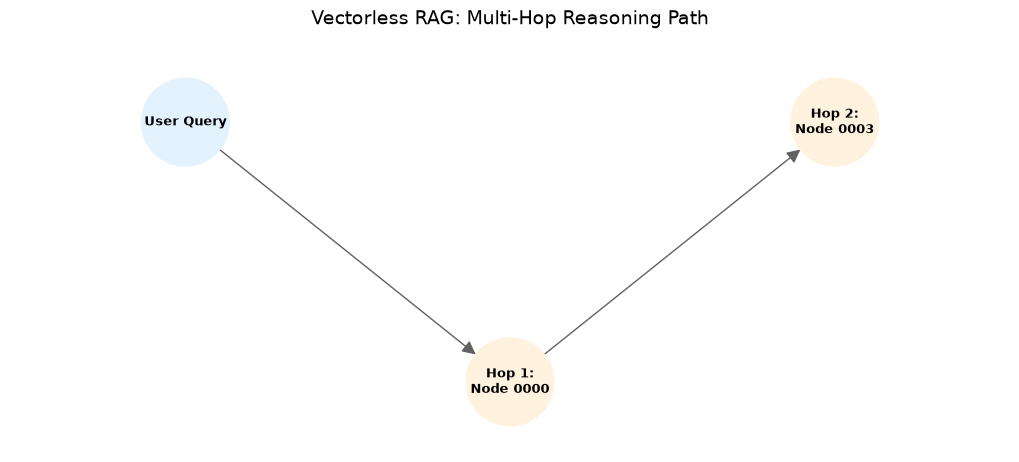

In [ ]:
# Call the function with our results
plot_traversal(result["hops"])

### Define Structured Data Query

In [57]:
# Change this to a question about extracting specific values from a table
QUERY_STRUCTURED = "According to the Home Deliveries table, what was the exact number of homes delivered and the average sales price for the 'Texas' region in the first quarter of 2025?"

### Retrieve Nodes for Structured Data

In [65]:
result = retrieve_nodes(QUERY_STRUCTURED)

print("--- Table Analysis Path (Structured Data) ---")
for step in result["hops"]:
    print(f"Step {step['step']} (Table Node {step['node_id']}): {step['reason']}")

print("\nFinal Nodes Retrieved:", result["node_list"])

--- Table Analysis Path (Structured Data) ---
Step 1 (Table Node 0000): Started with the main report to understand the context of Century Communities' Q1 2025 results.
Step 2 (Table Node 0001): Moved to the detailed Q1 2025 results to find specific operational metrics.
Step 3 (Table Node 0009): Navigated to the Home Deliveries section for detailed information on home deliveries.
Step 4 (Table Node 0008): Checked the Net New Home Contracts section for regional breakdowns, realizing it might contain or lead to the necessary home deliveries data.

Final Nodes Retrieved: ['0000', '0001', '0009', '0008']


### Answer Structured Data Query

In [ ]:
context = get_context(result["node_list"])
answer = call_llm(f"Context:\n{context}\n\nQuestion: {QUERY_STRUCTURED}\n\nAnswer concisely.")
print("Answer:", answer)

Answer: In the first quarter of 2025, the 'Texas' region delivered 457 homes with an average sales price of $298.9 thousand.


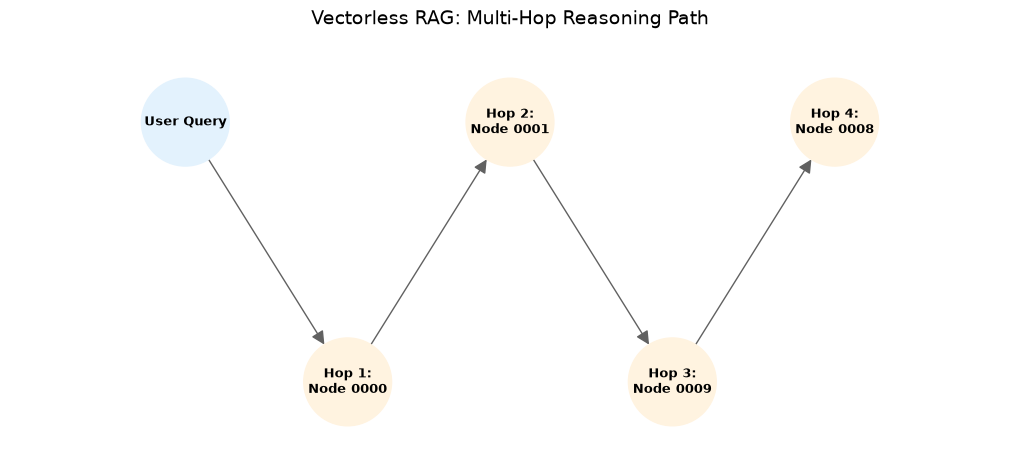

In [68]:
# Generate the visual plot for the table extraction
plot_traversal(result["hops"])

---
## Try It Yourself

Change the `QUERY_*` variables and re-run the cells. Here are some generic patterns to try: